In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Fix the seed so our results are reproducible
np.random.seed(42)
print("Setup complete ✓")

Setup complete ✓


In [2]:
class RandomWalkEnv:
    """
    5-state random walk environment.
    Positions: 0=LEFT END, 1=A, 2=B, 3=C, 4=D, 5=E, 6=RIGHT END
    """

    def __init__(self):
        self.n_states = 7  # 0 to 6
        self.start_position = 3  # always start at C
        self.position = self.start_position

    def reset(self):
        """Resets the agent to the center state (C) to start a new episode."""
        self.position = self.start_position
        return self.position

    def step(self):
        """
        Moves the agent one RANDOM step (left or right, 50/50).
        Returns: (new_state, reward, episode_done)
        """
        # Random draw: -1 (left) or +1 (right), equally likely
        move = np.random.choice([-1, 1])
        self.position += move

        # Check whether a terminal state has been reached
        if self.position == 6:
            return self.position, 1.0, True  # RIGHT END: reward = 1
        elif self.position == 0:
            return self.position, 0.0, True  # LEFT END: reward = 0
        else:
            return self.position, 0.0, False  # episode continues, reward = 0

In [3]:
# Manual test: simulate one episode and print each step
env = RandomWalkEnv()
state = env.reset()
print(f"Start: position {state}")

n_steps = 0
done = False

while not done:
    n_steps = n_steps + 1
    state, reward, done = env.step()
    print(f"New position: {state}, reward: {reward}, done: {done}")

if reward == 1.0:
    result = "Win!"
else:
    result = "Loss :("

print(f"Number of steps: {n_steps} — result: {result}")
    

Start: position 3
New position: 2, reward: 0.0, done: False
New position: 3, reward: 0.0, done: False
New position: 2, reward: 0.0, done: False
New position: 1, reward: 0.0, done: False
New position: 0, reward: 0.0, done: True
Number of steps: 5 — result: Loss :(


In [4]:
# Hyperparameters
alpha = 0.1
n_episodes = 200

# Initialize V
V = np.ones(7) * 0.5
V[0] = 0.0
V[6] = 1.0

# Store a COPY of V after every episode
value_history = [V.copy()]

env = RandomWalkEnv()
print("V at the very start of this run:", np.round(V, 3))
for episode in range(n_episodes):
    state = env.reset()
    done = False

    while not done:
        old_state = state
        state, reward, done = env.step()

        if done:
            V[old_state] = V[old_state] + alpha * (reward - V[old_state])
        else:
            V[old_state] = V[old_state] + alpha * (V[state] - V[old_state])

    # Snapshot V at the end of EACH episode
    value_history.append(V.copy())
print("Number of snapshots saved:", len(value_history))
print(V)

V at the very start of this run: [0.  0.5 0.5 0.5 0.5 0.5 1. ]
Number of snapshots saved: 201
[0.         0.15772762 0.27463309 0.46050601 0.68454556 0.84674068
 1.        ]


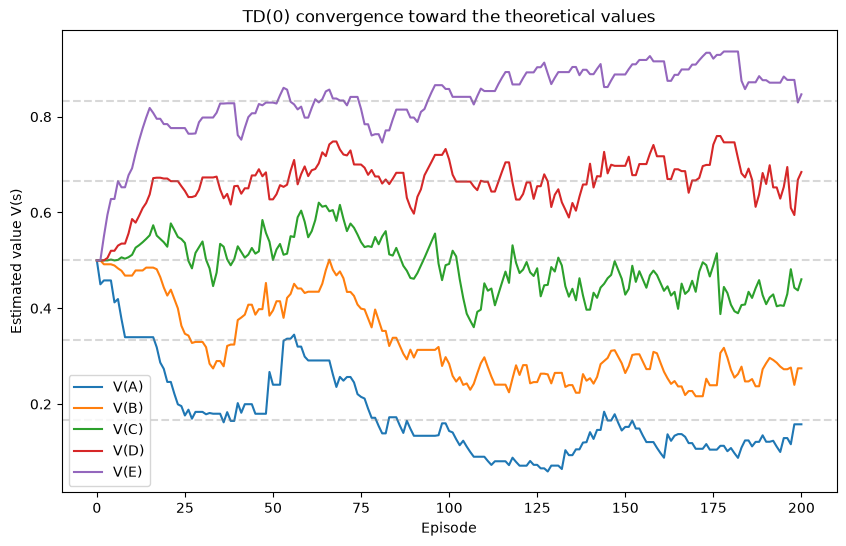

In [5]:
# Convert the list of arrays into one 2D array
# Each row = one episode, each column = one state
value_history = np.array(value_history)

plt.figure(figsize=(10, 6))

# One curve per non-terminal state (A, B, C, D, E)
labels = ['A', 'B', 'C', 'D', 'E']
for i, label in enumerate(labels):
    state_index = i + 1  # A=1, B=2, C=3, D=4, E=5
    plt.plot(value_history[:, state_index], label=f"V({label})")

# Horizontal lines for the true theoretical values
theoretical_values = [1/6, 2/6, 3/6, 4/6, 5/6]
for v_theo in theoretical_values:
    plt.axhline(y=v_theo, color='gray', linestyle='--', alpha=0.3)

plt.xlabel("Episode")
plt.ylabel("Estimated value V(s)")
plt.title("TD(0) convergence toward the theoretical values")
plt.legend()
plt.show()

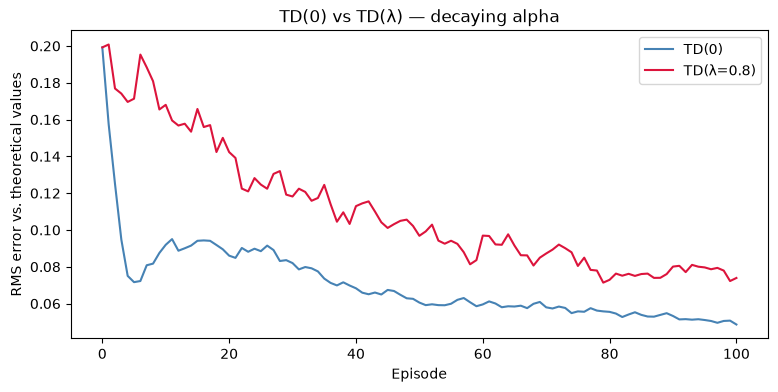

Final TD(0) error : 0.0486
Final TD(λ) error : 0.0739


In [6]:
# ============================================================
# TD(0) vs TD(lambda), with a decreasing learning rate (alpha)
# ============================================================

def td_lambda(n_episodes=100, alpha_start=0.5, lam=0.8):
    """TD(lambda) with alpha DECAYING over episodes."""
    V = np.ones(7) * 0.5
    V[0], V[6] = 0.0, 1.0
    history = [V.copy()]
    env = RandomWalkEnv()

    for episode in range(n_episodes):
        alpha = alpha_start / (1 + episode * 0.05)   # decay
        state = env.reset()
        done = False
        traces = np.zeros(7)

        while not done:
            old_state = state
            state, reward, done = env.step()
            delta = (reward - V[old_state]) if done else (V[state] - V[old_state])
            traces = lam * traces
            traces[old_state] += 1
            V = V + alpha * delta * traces
            V[0], V[6] = 0.0, 1.0

        history.append(V.copy())

    return np.array(history)


# --- Comparison over 50 runs ---
V_theoretical = np.array([0, 1/6, 2/6, 3/6, 4/6, 5/6, 1])
n_episodes, n_runs = 100, 50

err_td0 = np.zeros(n_episodes + 1)
err_lam = np.zeros(n_episodes + 1)

for run in range(n_runs):
    h0 = td_lambda(n_episodes, alpha_start=0.5, lam=0.0)
    hl = td_lambda(n_episodes, alpha_start=0.5, lam=0.8)
    err_td0 += np.sqrt(np.mean((h0 - V_theoretical)**2, axis=1))
    err_lam += np.sqrt(np.mean((hl - V_theoretical)**2, axis=1))

err_td0 /= n_runs
err_lam /= n_runs

plt.figure(figsize=(9, 4))
plt.plot(err_td0, label="TD(0)", color='steelblue')
plt.plot(err_lam, label="TD(λ=0.8)", color='crimson')
plt.xlabel("Episode")
plt.ylabel("RMS error vs. theoretical values")
plt.title("TD(0) vs TD(λ) — decaying alpha")
plt.legend()
plt.show()

print("Final TD(0) error :", round(err_td0[-1], 4))
print("Final TD(λ) error :", round(err_lam[-1], 4))

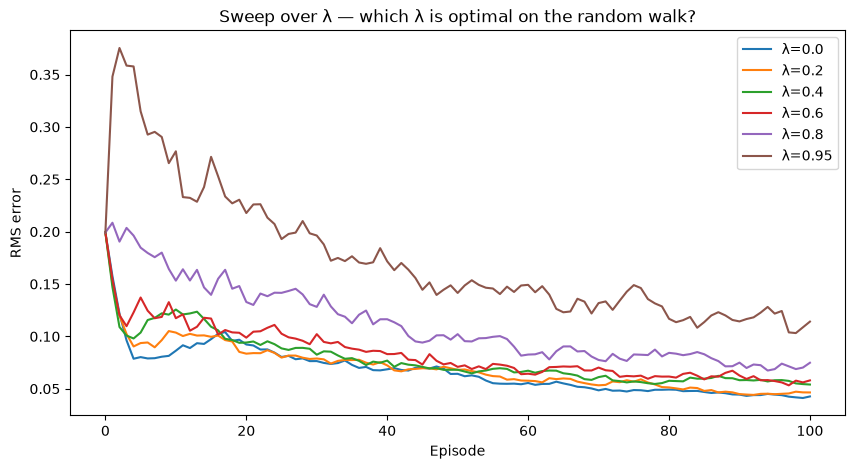

In [7]:
lambdas = [0.0, 0.2, 0.4, 0.6, 0.8, 0.95]
n_episodes, n_runs = 100, 50
V_theoretical = np.array([0, 1/6, 2/6, 3/6, 4/6, 5/6, 1])

plt.figure(figsize=(10, 5))

for lam in lambdas:
    errors = np.zeros(n_episodes + 1)
    for run in range(n_runs):
        h = td_lambda(n_episodes, alpha_start=0.5, lam=lam)
        errors += np.sqrt(np.mean((h - V_theoretical)**2, axis=1))
    errors /= n_runs
    plt.plot(errors, label=f"λ={lam}")

plt.xlabel("Episode")
plt.ylabel("RMS error")
plt.title("Sweep over λ — which λ is optimal on the random walk?")
plt.legend()
plt.show()